In [1]:
################################################################################
                    # Environment setup #
################################################################################
import os
import sys
import stlearn as st
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
scripts_path = '/scratch/user/uqqvo1/Medulloblastoma_analysis/scripts/'
sys.path.append(scripts_path)
from X1_QC_SpeciesClassify import QC_helpers as QC_hs
from utils import helpers as hs
import matplotlib
from visualisation import helpers as vhs
from preprocessing.QC import cell_QC as cell_QC

out_plots = 'figure_components/QC_figure/'
hs.setUp()

samples_ = ['Visium94_A1_Hybrid_treated/', 'Visium94_B1_Hybrid_treated/',
            'Visium94_C1_Hybrid_untreated/', 'Visium94_D1_Hybrid_untreated/']
samples_2 = ['A/', 'B/', 'C/', 'D/']



In [2]:
################################################################################
                    # Loading in the data #
################################################################################
prefixes = ['A1-', 'B1-', 'C1-', 'D1-']

# Filtering the spots #
filt_files = np.array( os.listdir(hs.data_dir+'filter_ids/') )
filt_files = filt_files[np.argsort(filt_files)]
spot_filters = [pd.read_csv(hs.data_dir+'filter_ids/'+filt_file,
                           header=None).values[:,0] for filt_file in filt_files]
for i in range(len(spot_filters)):
    spot_filters[i] = [prefixes[i]+bc for bc in spot_filters[i]]

datas = [hs.load_(hs.data_dir+samples_[i], prefixes[i])[spot_filters[i],:]
         for i in range(len(samples_))]

# Make variable names unique in each AnnData object
for data in datas:
    data.var_names_make_unique()

/home/uqqvo1/.conda/envs/MB/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/uqqvo1/.conda/envs/MB/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/uqqvo1/.conda/envs/MB/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/uqqvo1/.conda/envs/MB/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


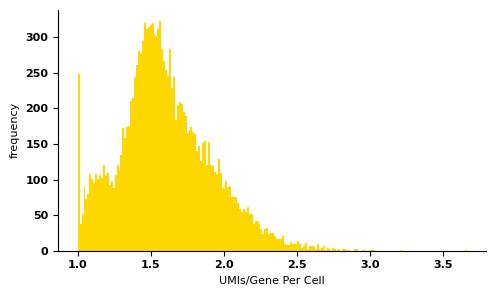

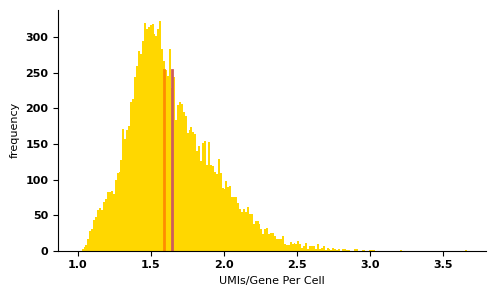

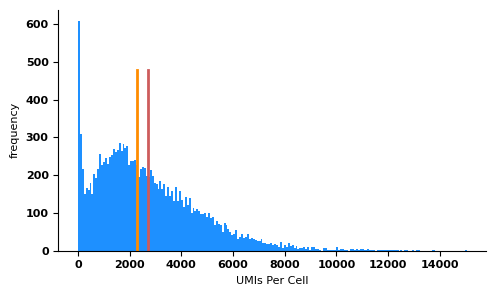

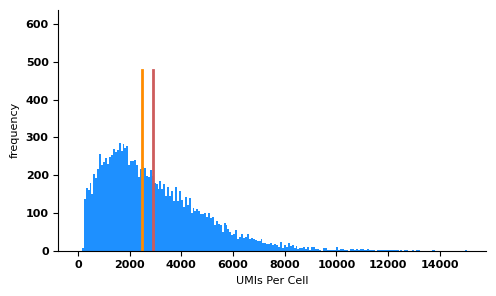

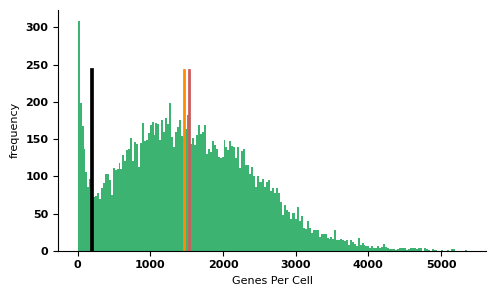

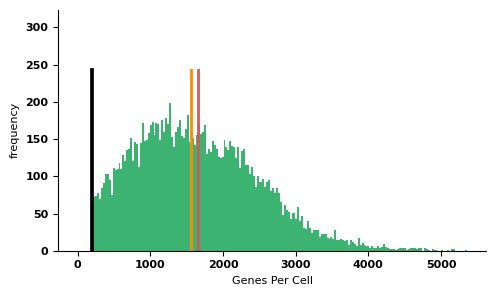

In [3]:
################################################################################
                # Performing QC spot filtering #
################################################################################
#[sc.pp.filter_genes(data, min_cells=5) for data in datas]

dfs = [data.to_df() for data in datas]
df_all = pd.concat(dfs).transpose()
df_all.values[np.isnan(df_all.values)] = 0 #Removing nans

count_gene_ratios, umis, gene_counts = cell_QC.getQCMetrics(df_all)
# after filtering minimums: 1.03827, 217, 200

matplotlib.rcParams.update({'font.size': 8, 'font.weight': 'bold'})
cutoffs = [0, 0, 200]
sf = f'MBVisium_'
passed = cell_QC.plotQCHistograms(count_gene_ratios, umis, gene_counts, cutoffs,
                                  folder=out_plots, savePlot=True,
                                  suffix=sf,
                                  linewidth=2, figsize=(5, 3), showPlot=True
                                  )

stats = cell_QC.getQCStats(count_gene_ratios, umis, gene_counts, cutoffs,
                          saveFile=True, folder='data/spot_meta/QC/', suffix=sf)

In [4]:
stats

,nCells,gene_counts_cutoff,gene_counts_cutoff,gene_counts_cutoff,umi_gene_ratio_minimum,umi_gene_ratio_median,umi_gene_ratio_mean,umi_gene_ratio_maximum,umis_minimum,umis_median,umis_mean,umis_maximum,gene_counts_minimum,gene_counts_median,gene_counts_mean,gene_counts_maximum
before,14982.0,0.0,0.0,0.0,1.000000,NaN,NaN,3.663135,0.0,2296.0,2703.492858,15034.0,0.0,1469.0,1531.249833,5352.0
after,13841.0,0.0,0.0,200.0,1.033816,1.590863,1.642832,3.663135,214.0,2496.0,2919.422513,15034.0,201.0,1564.0,1651.303880,5352.0


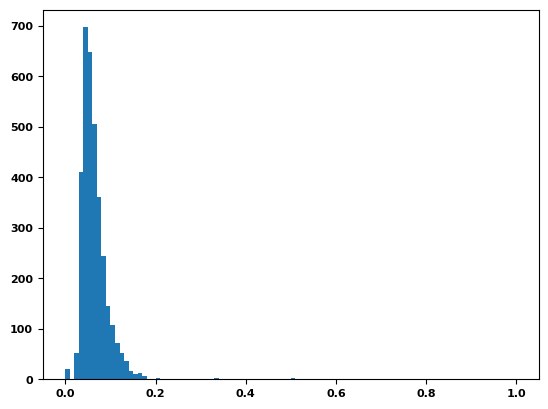

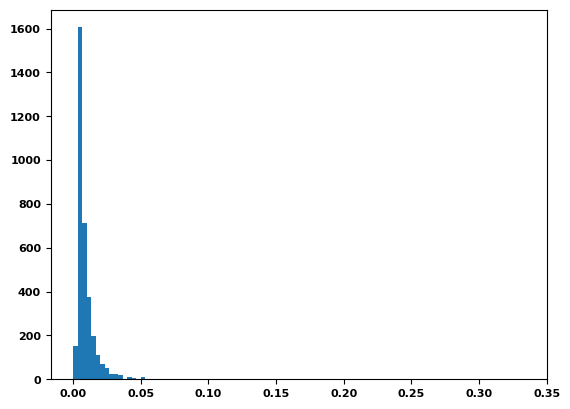

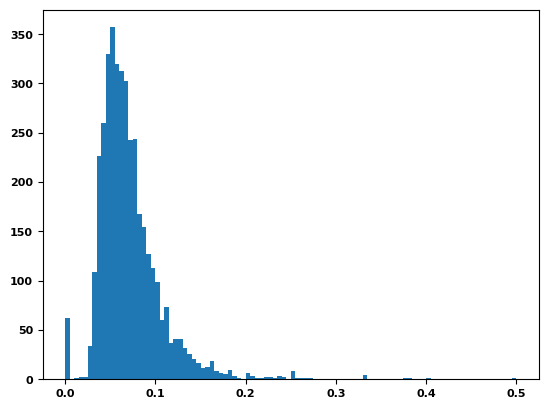

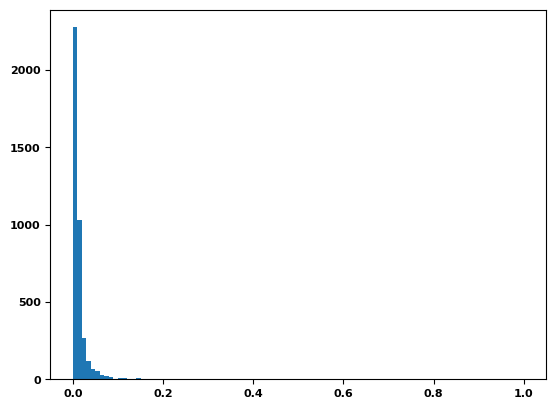

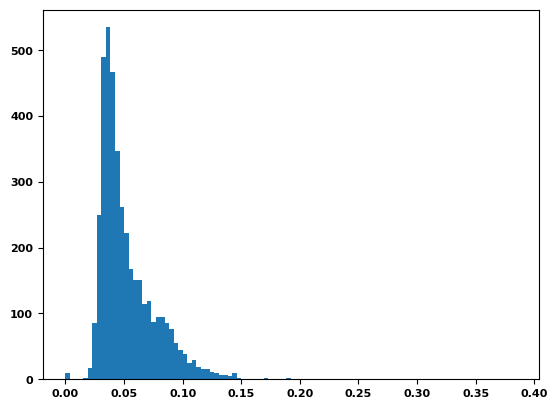

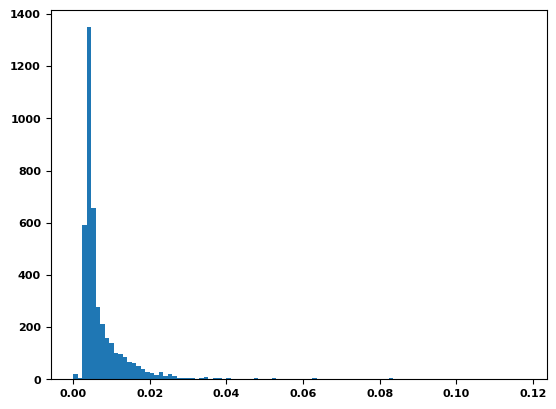

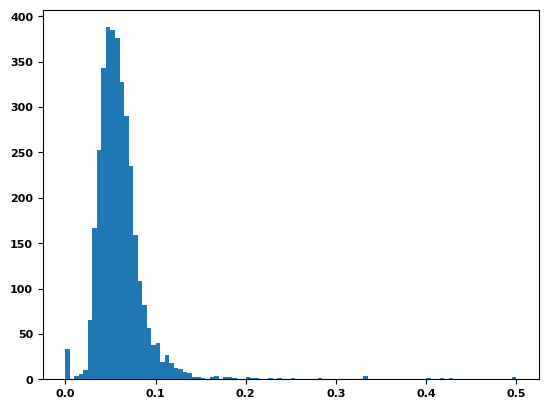

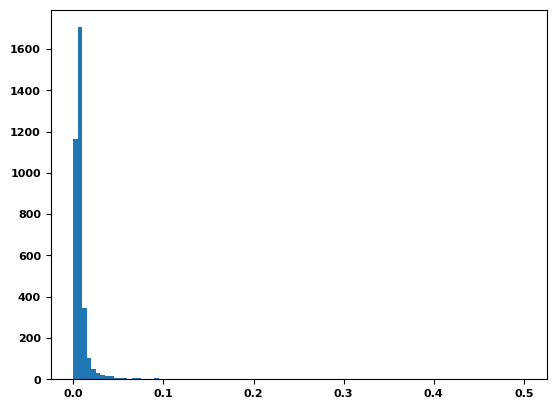

In [5]:
################################################################################
                    # Performing spot QC #
################################################################################
# Identifying ribosomal & mitochondrial genes #
genes = datas[0].var_names
ribo = [gene for gene in genes if \
        '-RPL' in gene or '-RPS' in gene or \
        '-Rpl' in gene or '-Rps' in gene]
mito = [gene for gene in genes if '-MT-' in gene or '-mt-' in gene]
good_genes = [gene for gene in genes if gene not in ribo and gene not in mito]

# Getting percentage of ribo/mito genes expressed per spot #
ribo_gene_perc = [QC_hs.getGenePercents(data, ribo, n_expr=True)
                                                              for data in datas]
ribo_count_perc = [QC_hs.getGenePercents(data, ribo, n_expr=False)
                                                              for data in datas]

mito_gene_perc = [QC_hs.getGenePercents(data, mito, n_expr=True)
                                                              for data in datas]
mito_count_perc = [QC_hs.getGenePercents(data, mito, n_expr=False)
                                                              for data in datas]

for i in range(len(datas)):
    plt.hist(ribo_gene_perc[i], bins=100)
    plt.show()

    plt.hist(mito_gene_perc[i], bins=100)
    plt.show()


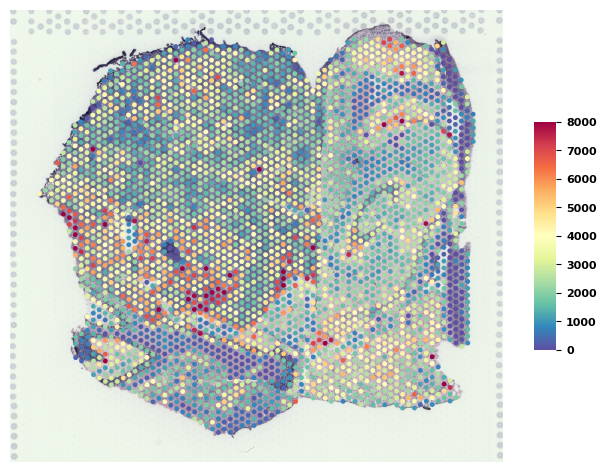

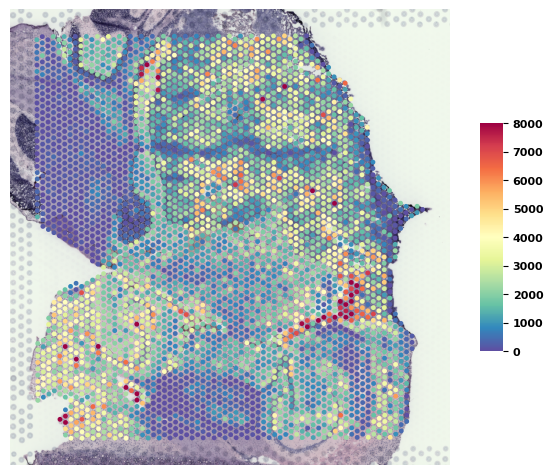

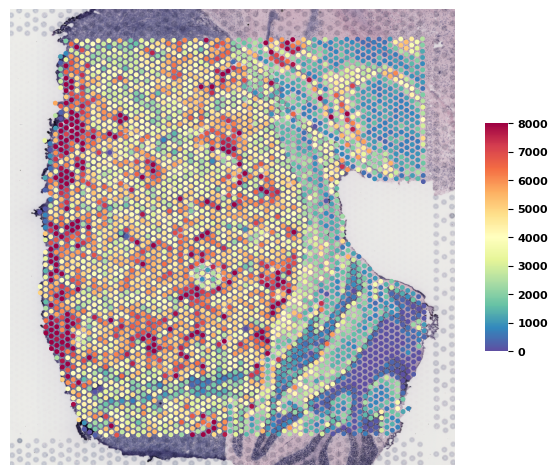

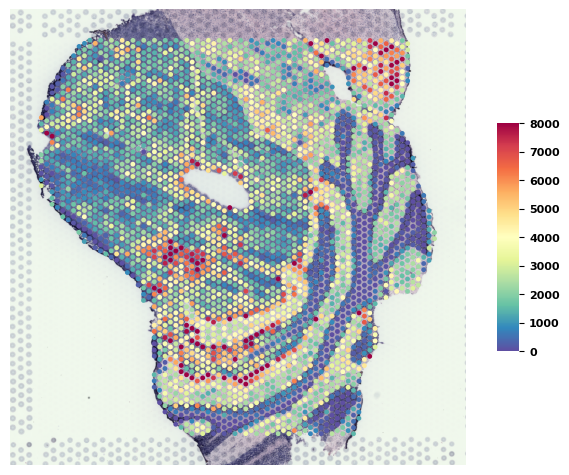

In [6]:
################################################################################
            # Visualising total counts after filtering genes #
################################################################################
mins, maxs = [], []
sample_counts = []
for i, data in enumerate(datas):
    df = data.to_df()
    tot_counts = df.values.sum(axis=1)
    min_counts = min(tot_counts)
    max_counts = max(tot_counts)
    mins.append( min_counts )
    maxs.append( max_counts )

    data.obsm['total_counts'] = tot_counts
    sample_counts.append(tot_counts)

min_counts = 0#min(mins)
max_counts = 8000#np.min(maxs)

r_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('rcmap',
                                    [(0, 0, 0)]+[(.6, 0, 0)]*1+[(.7, 0, 0)]*1+\
                                    [(.8, 0, 0)]*1+[(.9, 0, 0)]*4+[(.95, 0, 0)])

for i, data in enumerate(datas):
    st.pl.het_plot(data, cmap='Spectral_r',#r_cmap,
                   size=12,
                   use_het='total_counts', vmin=min_counts, vmax=max_counts)
    vhs.dealWithPlot(True, True, True, out_plots,
                     f'{samples_[i].split("_")[1]}_total_counts.pdf', dpi=300)


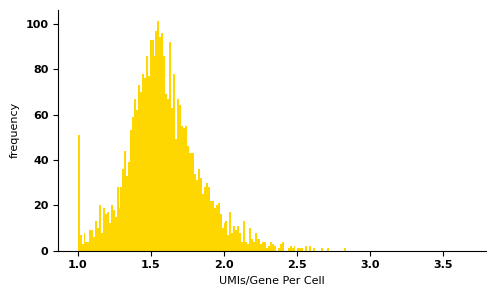

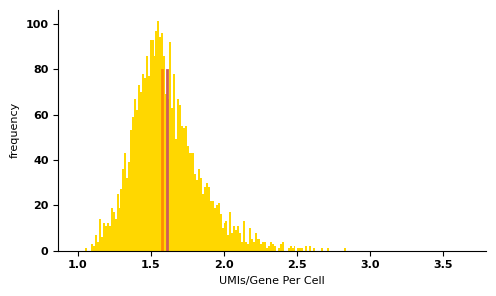

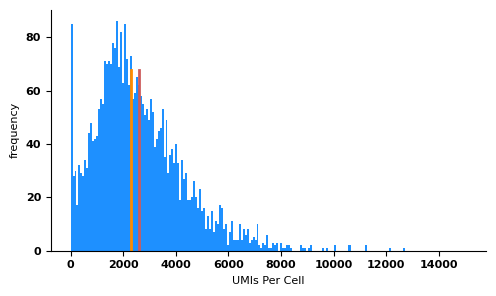

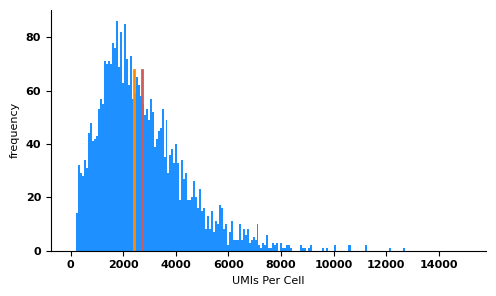

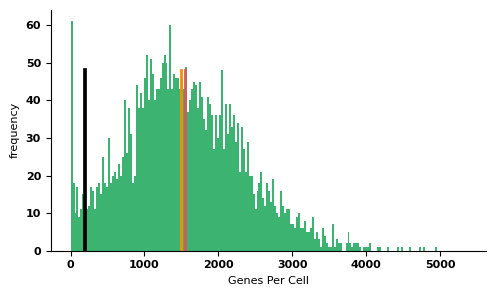

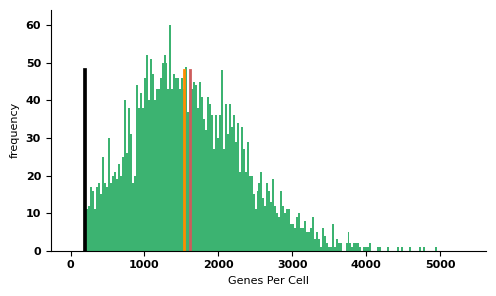

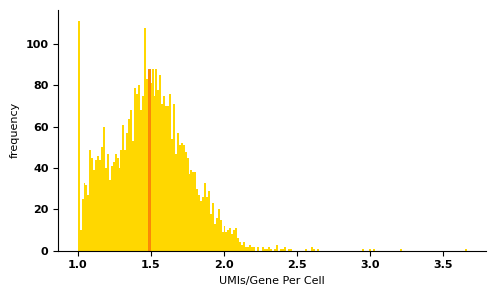

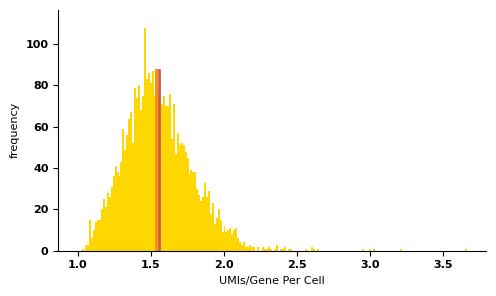

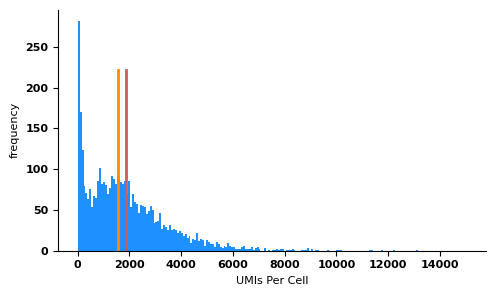

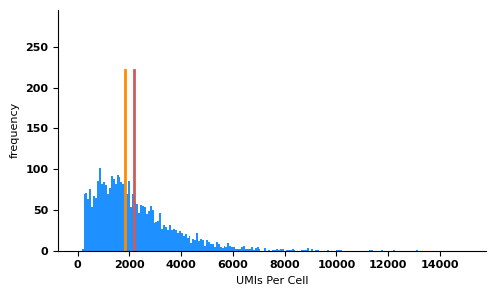

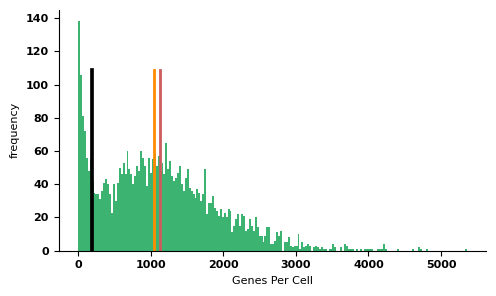

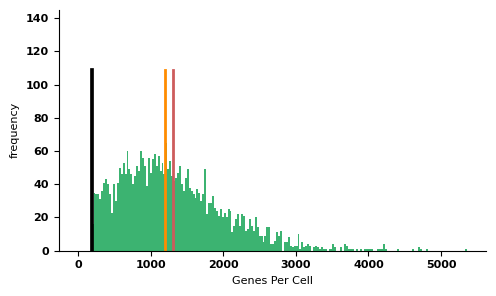

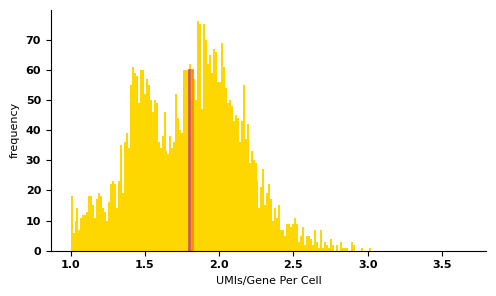

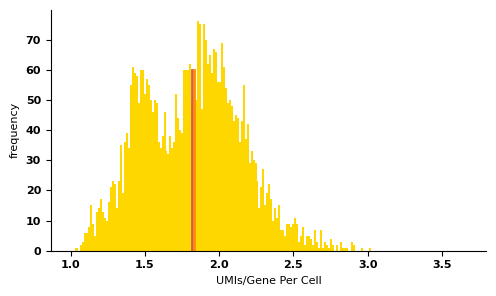

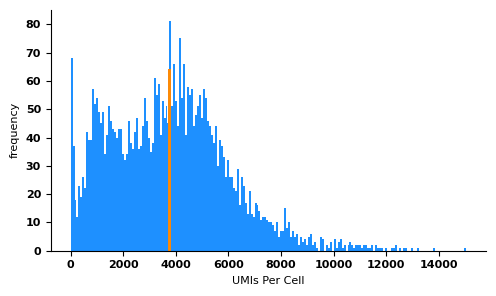

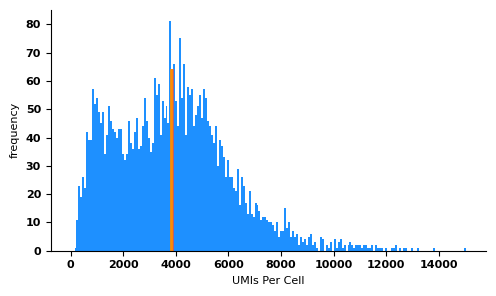

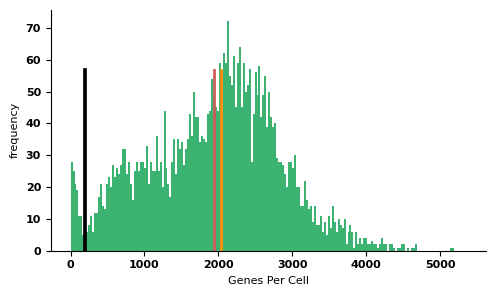

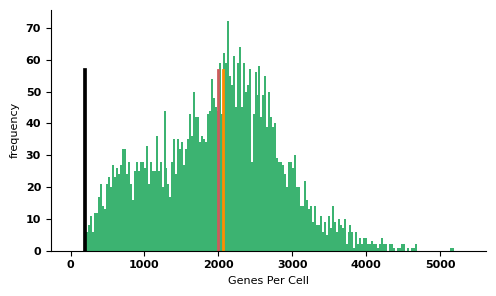

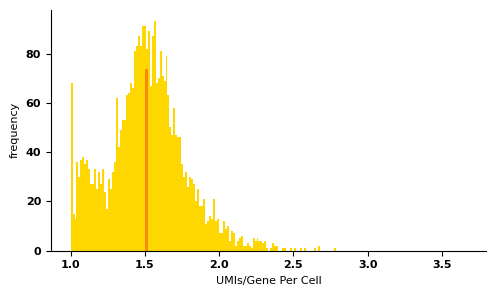

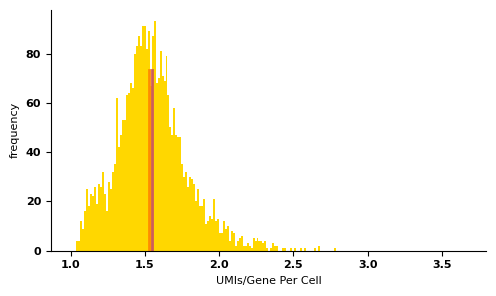

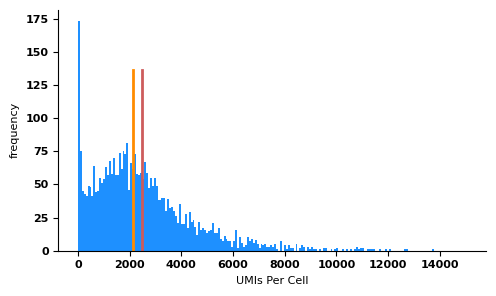

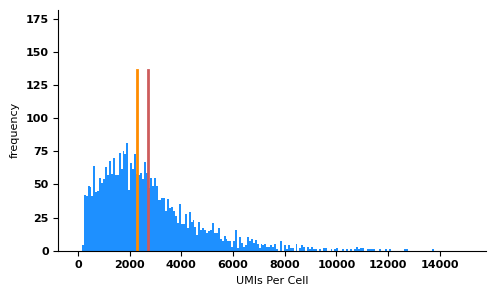

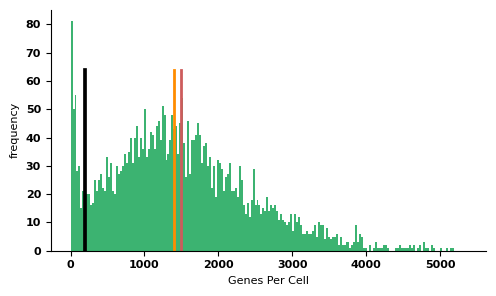

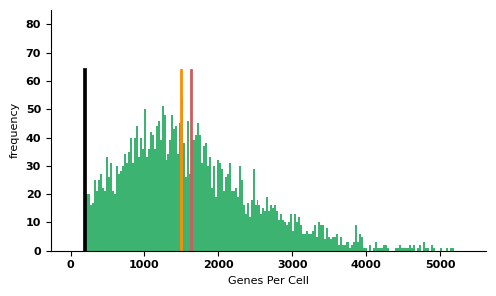

A1-
umis_median              2401.000000
umis_mean                2731.075275
gene_counts_median       1533.000000
gene_counts_mean         1611.408813
umi_gene_ratio_median       1.575072
umi_gene_ratio_mean         1.608653
Name: after, dtype: float64


B1-
umis_median              1818.000000
umis_mean                2170.710872
gene_counts_median       1196.000000
gene_counts_mean         1304.770609
umi_gene_ratio_median       1.533213
umi_gene_ratio_mean         1.555885
Name: after, dtype: float64


C1-
umis_median              3798.000000
umis_mean                3870.656943
gene_counts_median       2066.000000
gene_counts_mean         1994.332835
umi_gene_ratio_median       1.832497
umi_gene_ratio_mean         1.817537
Name: after, dtype: float64


D1-
umis_median              2281.500000
umis_mean                2703.742377
gene_counts_median       1490.500000
gene_counts_mean         1624.757934
umi_gene_ratio_median       1.530021
umi_gene_ratio_mean         1.550128
Name: 

In [7]:
################################################################################
       # Performing QC spot filtering for each sample indepedently #
################################################################################
dfs_t = [df.transpose() for df in dfs]

# To make sure on the same x-axis scale #
mins = [min(vals) for vals in [count_gene_ratios, umis, gene_counts]]
maxs = [max(vals) for vals in [count_gene_ratios, umis, gene_counts]]
valRanges = [(mins[i], maxs[i]) for i in range(len(mins))]

sample_stats = []
for i, df in enumerate(dfs_t):
    prefix = prefixes[i]

    count_gene_ratios, umis, gene_counts = cell_QC.getQCMetrics(df)

    matplotlib.rcParams.update({'font.size': 8, 'font.weight': 'bold'})
    cutoffs = [0, 0, 200]
    sf = f'MBVisium_{prefix}'
    passed = cell_QC.plotQCHistograms(count_gene_ratios, umis, gene_counts,
                                      cutoffs,
                                      folder=out_plots, savePlot=True,suffix=sf,
                                      linewidth=2, figsize=(5, 3), showPlot=True,
                                      ratioValRange=valRanges[0],
                                      umiValRange=valRanges[1],
                                      geneValRange=valRanges[2]
                                      )

    stats = cell_QC.getQCStats(count_gene_ratios, umis, gene_counts, cutoffs,
                               saveFile=True, folder='data/spot_meta/QC/',
                               suffix=sf)
    sample_stats.append( stats )

cols = ['umis_median', 'umis_mean', 'gene_counts_median', 'gene_counts_mean',
        'umi_gene_ratio_median', 'umi_gene_ratio_mean']
for i in range(len(sample_stats)):
    print(prefixes[i])
    print(sample_stats[i].loc['after',cols])
    print('\n')